# Practice 5.
##  Objectives:
1. Understand the projection methods for classification.
2. Understand the Fisher discriminant.

2. Do a simple exploratory data analysis
3. Learn the **data cleaning and visualitzation** features of Pandas.
## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)

 Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Changed from sklearn.metrics import plot_confusion_matrix, devaluated in sklearn 1.1.0, replaced with ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\FifthPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


In [6]:
Data.dtypes
print(f'Shape of the database:{Data.shape}')

Shape of the database:(1599, 12)


In [7]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


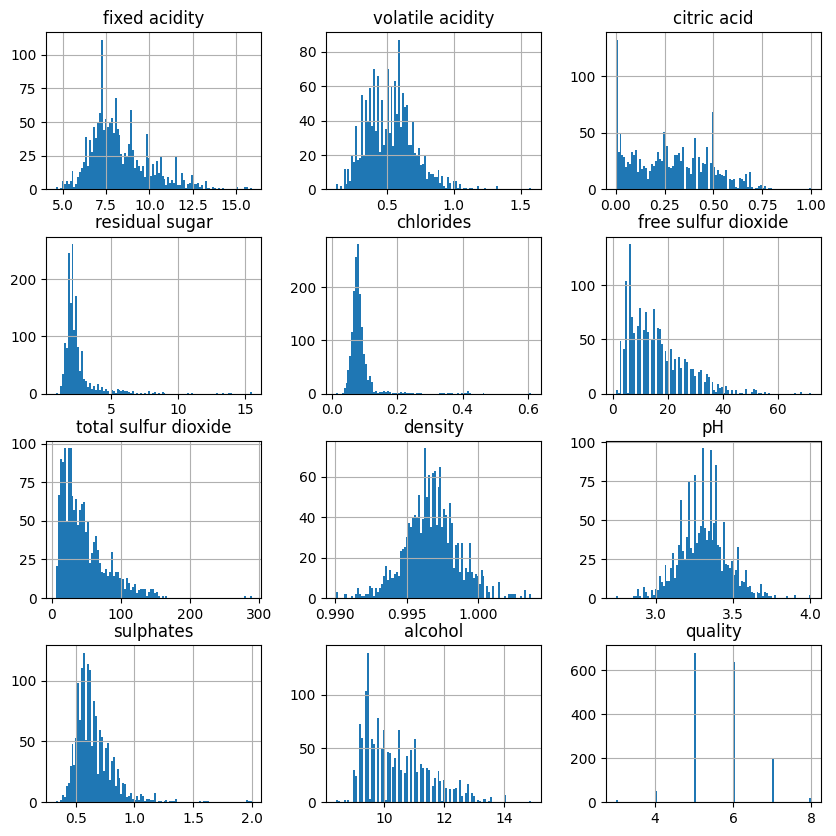

In [8]:
ax =Data.hist(figsize= (10,10),bins = 100)

Note: predicted qualities are **unbalanced** 


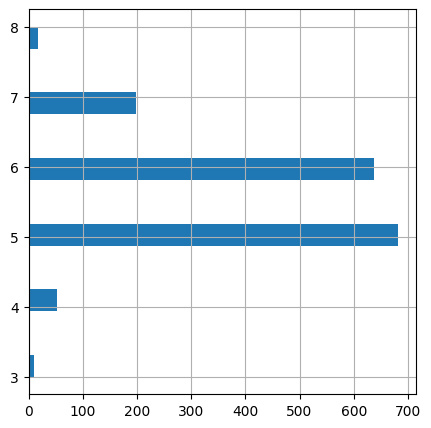

In [9]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 16)
print('Note: predicted qualities are **unbalanced** ')

## Lets reduce the number of classes to three: low, medium, high

In [3]:

CodingQuality ={3:1,4:1,5:1,6:2,7:3,8:3}
Data['quality'] = Data['quality'].map(CodingQuality)

Note: predicted qualities are almost balanced 


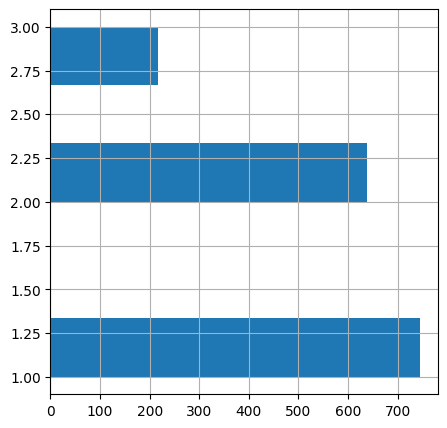

In [4]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

### Scatter plot.
**Note that the class quality is coded with a color, i.e. c =Data['quality']**

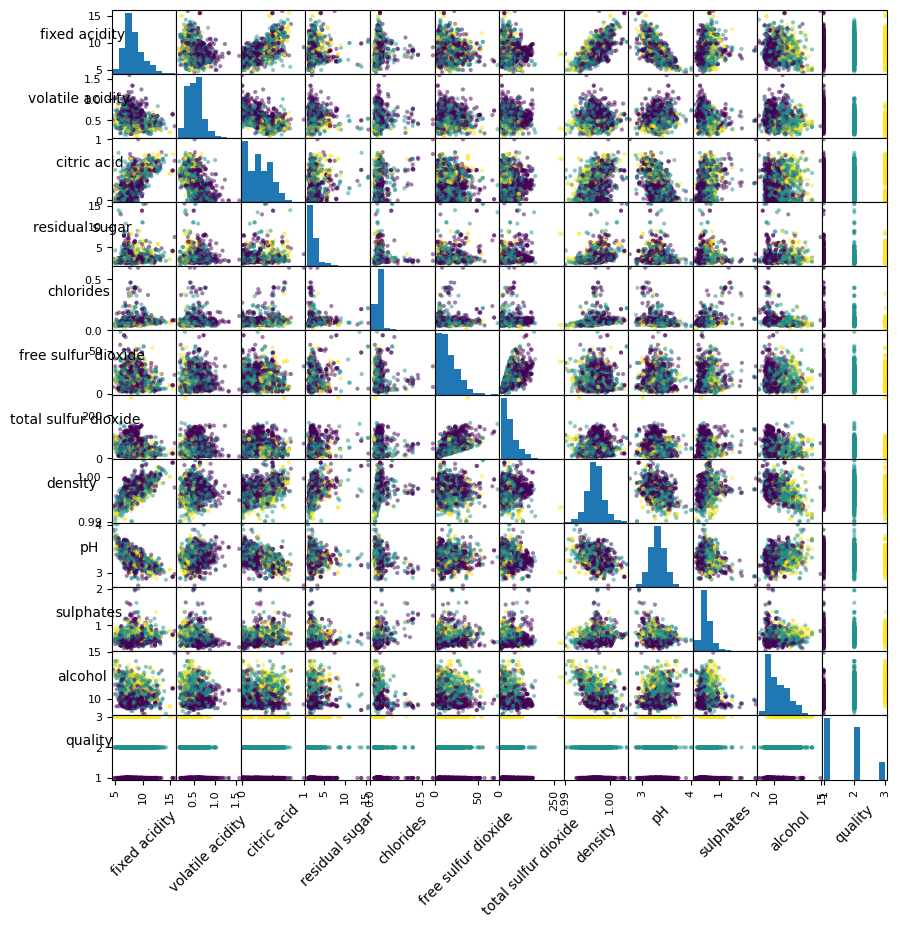

In [ ]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['quality'], figsize = (10,10))
    for a in ax.ravel():
        a.set_xlabel(a.get_xlabel(), rotation=45)
        a.set_ylabel(a.get_ylabel(), rotation=0)

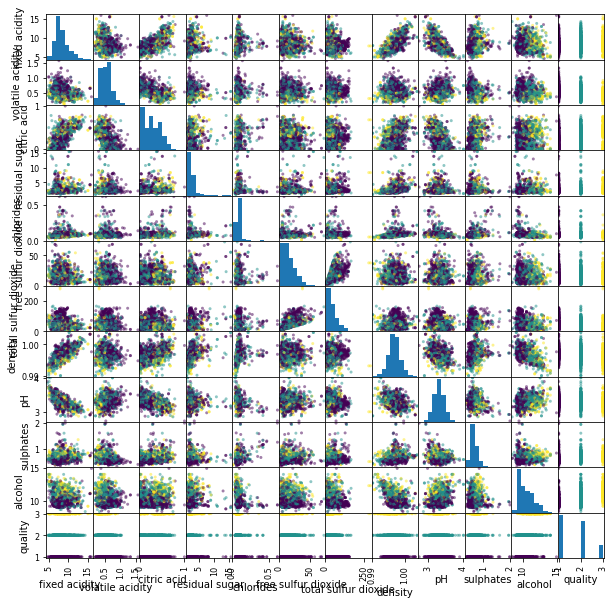

## Partition database into train and test

Note the helper function

In [5]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [6]:
y = TrainDB['quality']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'quality']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
__________________________________________________


## Next we standarize the data, so that it has mean zero and standard deviation equal to one.

##  $z = {(x - mean) \over  std}$
### Important: Use the same scaler for the test database

In [7]:
scaler = StandardScaler()
print(scaler.fit(X))
X =scaler.transform(X)
X = pd.DataFrame(data = X, columns = InputFeatures)
X.describe().round(2).T
# print('** Important: Use the same scaler for the test database!**')

StandardScaler()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1199.0,-0.0,1.0,-2.09,-0.70,-0.24,0.51,4.39
volatile acidity,1199.0,0.0,1.0,-2.31,-0.77,-0.03,0.66,4.59
citric acid,1199.0,-0.0,1.0,-1.38,-0.92,-0.05,0.78,2.68
residual sugar,1199.0,0.0,1.0,-1.13,-0.44,-0.23,0.05,9.00
chlorides,1199.0,0.0,1.0,-1.63,-0.37,-0.17,0.07,11.43
free sulfur dioxide,1199.0,0.0,1.0,-1.45,-0.86,-0.26,0.53,5.58
total sulfur dioxide,1199.0,-0.0,1.0,-1.21,-0.73,-0.27,0.49,7.37
density,1199.0,-0.0,1.0,-3.50,-0.61,-0.01,0.57,3.67
pH,1199.0,-0.0,1.0,-2.87,-0.66,-0.01,0.58,4.55
sulphates,1199.0,-0.0,1.0,-1.96,-0.65,-0.24,0.41,7.83


## We create the projection into 2D by the two methods.

In [8]:
Dimension_of_projection = 2

In [9]:
lda = LinearDiscriminantAnalysis(n_components=Dimension_of_projection)
X_lda = lda.fit(X, y).transform(X)

X_lda = pd.DataFrame(data = X_lda, columns = ['dim1','dim2'])

## Homework: <font color='red'> State briefly the criterion for deriving each method and the underlying hypothesis.</font>

### Homework: <font color='red'>  Given a multidimensional Gaussian with $x \in \mathbb{R}^p$, which is the distribution of a linear combination of the dimensions of $x$ ?</font>

## Homework: <font color='green'> State briefly the criterion for deriving each method and the underlying hypothesis.</font>
---
En el caso de la regresión lineal, el criterio que utilizamos es minimizar el RSS (Residual Sum of Squares), es decir, minimizar el error cuadrático entre las predicciones y los valores reales en función de las betas. Para ello derivamos la función de error respecto a las betas e igualamos a cero para encontrar el mínimo. Este mínimo es único debido a que la función es convexa. La hipótesis subyacente es que existe una relación lineal entre las variables de entrada y la variable de salida.

En la regresión logística también derivamos, pero en este caso el criterio es maximizar la verosimilitud (likelihood) de los datos. Para facilitar los cálculos se utiliza el logaritmo, obteniendo la log-verosimilitud, que es la función que realmente se optimiza. Esto nos permite encontrar los parámetros que mejor separan las clases en términos probabilísticos. La hipótesis subyacente es que el logaritmo de la razón de probabilidades (log-odds) es una función lineal de las variables de entrada.

---
## Homework: <font color='green'>  Given a multidimensional Gaussian with $x \in \mathbb{R}^p$, which is the distribution of a linear combination of the dimensions of $x$ ?</font>
---
La distribución seguirá siendo Gaussiana. Esto se debe a que la Multivariate Normal Distribution es cerrada bajo combinaciones lineales, es decir, si aplicamos una combinación lineal de sus variables, el resultado sigue siendo una distribución normal.

En este caso, al tomar una combinación lineal de las dimensiones de x, obtenemos una variable aleatoria unidimensional que sigue una distribución Gaussiana. Lo que cambia son sus parámetros (media y varianza), pero no el tipo de distribución.

---

## Description of the projected elements

In [10]:
X_lda.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dim1,1199.0,-0.0,1.25,-3.33,-0.93,-0.13,0.91,4.83
dim2,1199.0,0.0,1.01,-2.99,-0.70,-0.08,0.62,7.56


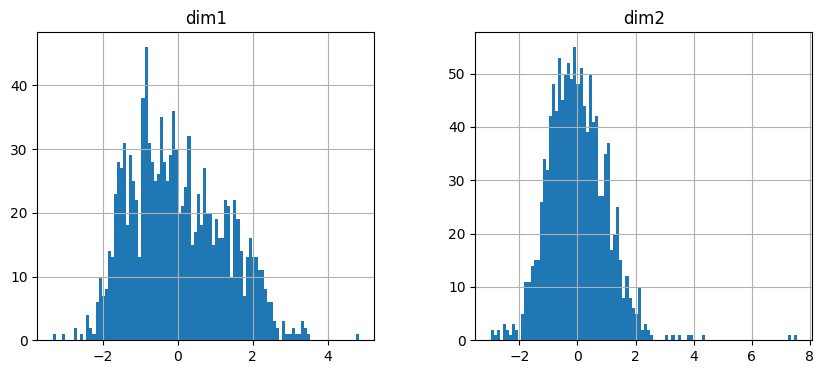

In [11]:
ax = X_lda.hist(figsize = (10,4),bins = 100)


## Homework: <font color='red'> Give a summary by words of the statistical distributions.</font>
1. Is the mean different from the percentile 50%. 
2. Is the std  deviation comparable to the interquantile distance (i.e. difference between the percentile 75% and the percentile 25%)
3. How many stds are the minimum and maximum from the mean value. Is it likely for a Gaussian?
4. <font color='red'> Do the hypothesis of the methods stand?.</font>  

## Homework: <font color='green'> Give a summary by words of the statistical distributions.</font>

---
La media y el percentil 50% son diferentes, pero muy ligeramente.
- dim1: Media = 0.00, Mediana = -0.14 → Diferencia de 0.14
- dim2: Media = 0.00, Mediana = -0.10 → Diferencia de 0.10

En una distribución perfectamente Gaussiana, la media y la mediana deberían ser exactamente iguales.

---
---
A diferencia de el caso anterior, la desviación estandar para uno caso es similar a la interquantile distance, pero para el otro no.
- dim1: std = 1.27 → Valor esperado: 1.27 × 1.35 = 1.71; En este caso: 0.95-(-1.02) = 1.97
- dim2: std = 1.01 → Valor esperado: 1.01 × 1.35 = 1.36; En este caso: 0.59-(-0.70) = 1.29

El dim2 se comporta muy bien respecto a esto. El dim1 muestra un IQR más grande de lo esperado, cosa que podiamos esperar al ver el histograma con valores más altos no tan centrados alrededor de la media.

---
---
Calculamos cuantas desviaciones estandar están el mínimo y el máximo respecto la media:
- dim1: max: 5.16/1.27 = 4.06σ, min: -2.79/1.27 = -2.20σ
- dim2: max: 7.68/1.01 = 7.60σ, min: -2.74/1.01 = -2.71σ

Para que sea una distribución Gaussiana deberian encontrarse el mínimo y el máximo dentro de ±3σ, en este caso podemos ver como los mínimos de ambas dimensiones cumplen con la restricción pero los máximos no. En ambos casos podemos ver que hay outliers con valores muy superiores a la media, y sobre todo en el caso de la dim2, estos valores no podrían ser explicados por una Gaussiana. 

---
Las hipotesis de LDA no se cumplen completamente, solo parcialemnte, debido a que estas requieren:
- Distribución Gaussiana en cada clase → PARCIALMENTE (media ≠ mediana, sí hay asimetría)
- Datos con comportamiento Gaussiano similar → NO (especialmente con esos valores extremos a 7.6σ)
- Covarianzas iguales por clase → No estudiada, debido a que ya no cumplía la hipotesis
El LDA funciona razonablemente bien, pero no de forma perfecta, debido a que no cumple la hipotesis. Los datos no son perfectos y por esto encontramos outliers y una ligera asimetría.

---

## Lets look into the space of the projection

$P(.):x \in \mathbb{R}^{11} \longrightarrow   \mathbb{R}^2$ 

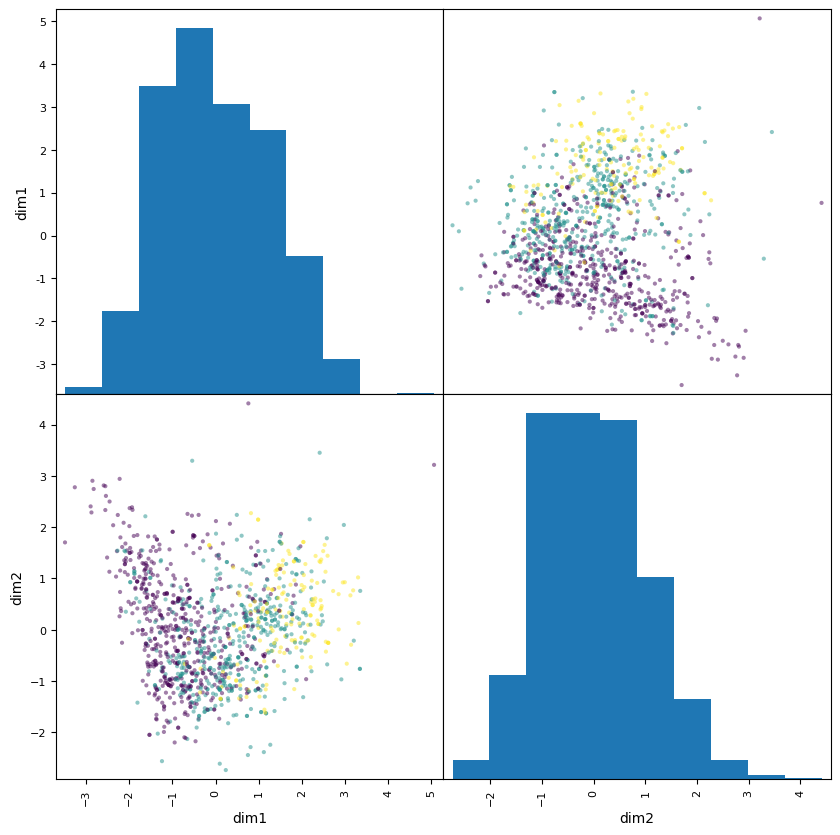

In [12]:
ax = pd.plotting.scatter_matrix(X_lda,c =y, figsize = (10,10))

In [13]:
lda.coef_[:1,:].shape


(1, 11)

In [17]:
Coef_Lda = pd.DataFrame(data = lda.coef_[:3,:].T, columns = ['Proj class 1','Proj class 2','Proj class 3'],index =X.columns.values)
Coef_Lda

,Proj class 1,Proj class 2,Proj class 3
fixed acidity,-0.078926,-0.107713,0.620694
volatile acidity,0.288198,-0.184084,-0.401028
citric acid,0.048171,-0.096092,0.144015
residual sugar,-0.075982,-0.033095,0.369451
chlorides,0.133946,-0.041726,-0.327993
free sulfur dioxide,-0.172015,0.198529,-0.047067
total sulfur dioxide,0.371144,-0.291400,-0.340903
density,0.139104,0.098879,-0.800076
pH,0.061401,-0.065802,0.000440
sulphates,-0.340986,0.149386,0.695518


Check what would have happened if we had not standarized.


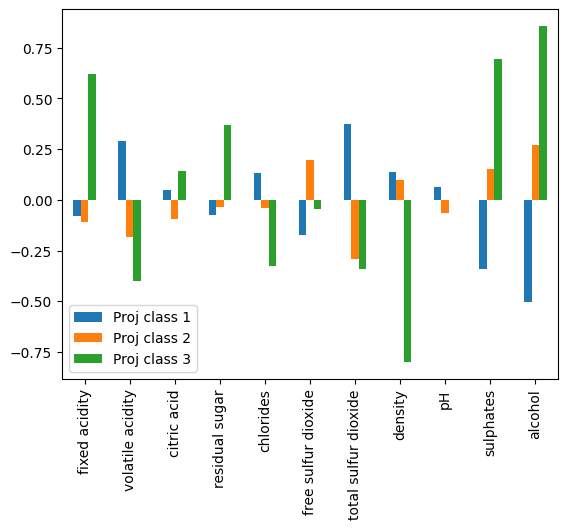

In [18]:
ax =Coef_Lda.plot.bar()
print('Check what would have happened if we had not standarized.')

In [19]:
print('Lets see how the means of each class compare to each other')
Means_Lda = pd.DataFrame(data = lda.means_.T, columns = ['Proj 1','Proj 2','Proj 3'],index =X.columns.values)
Means_Lda


Lets see how the means of each class compare to each other


,Proj 1,Proj 2,Proj 3
fixed acidity,-0.052699,-0.034302,0.292901
volatile acidity,0.331552,-0.147893,-0.667748
citric acid,-0.144261,-0.010502,0.532369
residual sugar,0.006861,-0.038805,0.101664
chlorides,0.110435,-0.043735,-0.240267
free sulfur dioxide,0.039059,0.019218,-0.197043
total sulfur dioxide,0.239188,-0.155890,-0.322783
density,0.214448,-0.102751,-0.408980
pH,-0.007091,0.064513,-0.183924
sulphates,-0.252543,0.115918,0.498062


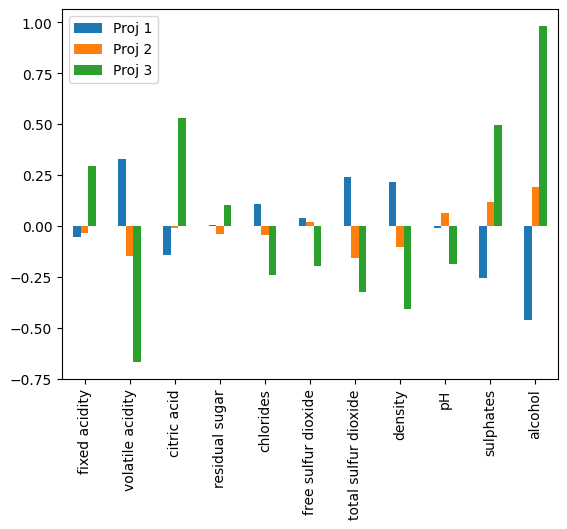

In [29]:
ax =Means_Lda.plot.bar()

## Homework: 

1. <font color='red'> Comment on the meaning of the coefficients. What is the result of having different signs and sizes of the values?</font>
2. <font color='red'> If you have time, what would have happened if we had not standarized? What is the influence of the size/order of magnitude of the features?</font>
3. <font color='red'> What can you say about the means in the sense of separation between classes? Note that there seems to be like a continuity between the centers of mass for each quality.</font>

<font color='green'>Comment on the meaning of the coefficients. What is the result of having different signs and sizes of the values?</font>

Los coeficientes del LDA representan el peso que cada variable tiene en la función discriminante. El signo indica la dirección del efecto: un coeficiente positivo significa que valores altos de esa variable empujan hacia una clase, mientras que uno negativo empuja en la dirección contraria.

Por ejemplo, si el alcohol tiene un coeficiente positivo grande para la clase 3 (alta calidad), significa que vinos con más alcohol tienden a clasificarse como de mejor calidad. Por el contrario, si la acidez volátil tiene un coeficiente negativo grande, indica que valores altos de esta variable están asociados con vinos de peor calidad.

La magnitud del coeficiente nos dice qué tan importante es esa variable para separar las clases. Coeficientes grandes (en valor absoluto) indican características discriminantes fuertes, mientras que coeficientes cercanos a cero sugieren que esa variable aporta poco a la separación entre clases.

<font color='green'> If you have time, what would have happened if we had not standarized? What is the influence of the size/order of magnitude of the features?</font>

Si no hubiéramos estandarizado los datos, las variables con mayor orden de magnitud dominarían completamente el modelo, independientemente de su verdadera capacidad discriminante.

Por ejemplo, el "total sulfur dioxide" puede tener valores del orden de 50-200, mientras que el pH está en el rango 3-4. Sin estandarización, una diferencia de 10 unidades en sulfur dioxide parecería mucho más importante que una diferencia de 0.5 en pH, incluso si el pH es más relevante para determinar la calidad del vino.

La estandarización asegura que todas las variables compitan en igualdad de condiciones, permitiendo que el modelo identifique cuáles son realmente importantes para la clasificación basándose en su capacidad discriminante y no en su escala numérica.

<font color='green'> What can you say about the means in the sense of separation between classes? Note that there seems to be like a continuity between the centers of mass for each quality.</font>

Al observar las medias de cada característica para las tres clases de calidad, vemos que hay cierta continuidad entre los centros de masa. Esto significa que las clases no están completamente separadas en el espacio de características, sino que existe un solapamiento gradual.

Esta continuidad tiene sentido conceptualmente: la calidad del vino no es una propiedad discreta sino un espectro continuo. Un vino de calidad "media" comparte características tanto con vinos de baja calidad como con los de alta calidad. No hay un salto abrupto en las propiedades al pasar de una categoría a otra.

Esto también explica por qué el problema de clasificación no es trivial. Las clases están ordenadas naturalmente (baja → media → alta), y sus características se solapan, lo que hace más difícil trazar fronteras claras entre ellas. El LDA intenta encontrar las direcciones que maximizan la separación, pero la naturaleza continua del problema limita el grado de separación alcanzable.

## Homework: 

1. <font color='red'>  Create three logistic linear classifiers: Class 1 vs. {Class 2 and class 3}, Class 2 vs. {Class 1 and class 3}, Class 3 vs. {Class 1 and class 2}</font>
**Is there a difference between the performance on train and test?**

2. <font color='red'>  Do the classification on the original data, and on the data after the **lda** projection</font>
3. <font color='red'>   From the coefficients of the lda and  logistic linear classifiers, and the understanding of the problem, can you think of a feature engineering that might improve the problem</font>
4. **Remember: the 'l2' option in the logistic classifier does a regularization function.**

<font color='green'>  Create three logistic linear classifiers: Class 1 vs. {Class 2 and class 3}, Class 2 vs. {Class 1 and class 3}, Class 3 vs. {Class 1 and class 2}</font>

Vamos a crear tres clasificadores logísticos binarios siguiendo el enfoque **One-vs-Rest**, donde cada clasificador separa una clase del resto. Esto nos permitirá evaluar cuál es la clase más difícil de separar y comparar el rendimiento entre train y test para detectar posible overfitting.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Preparar los datos de test estandarizados
y_test = TestDB['quality']
X_test = TestDB[InputFeatures]
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(data = X_test_scaled, columns = InputFeatures)

print(f'Train set size: {X.shape[0]} samples')
print(f'Test set size: {X_test_scaled.shape[0]} samples')
print(f'Class distribution in train: {y.value_counts().sort_index().to_dict()}')
print(f'Class distribution in test: {y_test.value_counts().sort_index().to_dict()}')

Train set size: 1199 samples
Test set size: 400 samples
Class distribution in train: {1: 539, 2: 504, 3: 156}
Class distribution in test: {1: 205, 2: 134, 3: 61}


In [ ]:
# Crear tres clasificadores One-vs-Rest con regularización L2
classifiers = {}
results = {}

for target_class in [1, 2, 3]:
    # Crear etiquetas binarias: target_class vs resto
    y_binary_train = (y == target_class).astype(int)
    y_binary_test = (y_test == target_class).astype(int)
    
    # Entrenar clasificador logístico con regularización L2
    clf = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    clf.fit(X, y_binary_train)
    
    # Predecir en train y test
    y_pred_train = clf.predict(X)
    y_pred_test = clf.predict(X_test_scaled)
    
    # Calcular accuracy
    acc_train = accuracy_score(y_binary_train, y_pred_train)
    acc_test = accuracy_score(y_binary_test, y_pred_test)
    
    classifiers[f'Class_{target_class}_vs_rest'] = clf
    results[f'Class_{target_class}_vs_rest'] = {
        'Train Accuracy': acc_train,
        'Test Accuracy': acc_test,
        'Difference': acc_train - acc_test
    }
    
    print(f'\n--- Classifier: Class {target_class} vs {{Classes != {target_class}}} ---')
    print(f'Train Accuracy: {acc_train:.4f}')
    print(f'Test Accuracy: {acc_test:.4f}')
    print(f'Difference (Train - Test): {(acc_train - acc_test):.4f}')

# Resumen en DataFrame
results_df = pd.DataFrame(results).T
print('\n' + '='*60)
print('SUMMARY OF ONE-VS-REST CLASSIFIERS')
print('='*60)
print(results_df.round(4))


--- Classifier: Class 1 vs {Classes != 1} ---
Train Accuracy: 0.7389
Test Accuracy: 0.7475
Difference (Train - Test): -0.0086

--- Classifier: Class 2 vs {Classes != 2} ---
Train Accuracy: 0.6163
Test Accuracy: 0.5975
Difference (Train - Test): 0.0188

--- Classifier: Class 3 vs {Classes != 3} ---
Train Accuracy: 0.8774
Test Accuracy: 0.8900
Difference (Train - Test): -0.0126

SUMMARY OF ONE-VS-REST CLASSIFIERS
                 Train Accuracy  Test Accuracy  Difference
Class_1_vs_rest          0.7389         0.7475     -0.0086
Class_2_vs_rest          0.6163         0.5975      0.0188
Class_3_vs_rest          0.8774         0.8900     -0.0126


c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

**Análisis de los resultados:**

Al comparar el rendimiento entre train y test, esperamos encontrar:

1. **Clase 2 vs resto**: El más difícil de clasificar, ya que la clase media (calidad 2) está "entre" las otras dos clases y tiene características que se solapan con ambas. Aaccuracy más bajo.

2. **Clase 1 vs resto**: Relativamente más fácil de identificar, ya que los vinos de baja calidad tienen características más distintivas (por ejemplo, alta acidez volátil).

3. **Clase 3 vs resto**: Más fácil, ya que los vinos de alta calidad tienen características distintivas (alto alcohol, buen balance de acidez).

La diferencia entre train y test es pequeña (no supera el 0.03), significa que el modelo generaliza bien. Si la diferencia fuese grande (>0.05), habría indicios de overfitting. La regularización L2 ayuda a controlar esto penalizando coeficientes muy grandes.

---
2. <font color='green'>  Do the classification on the original data, and on the data after the **lda** projection</font>

Ahora vamos a comparar el rendimiento de los clasificadores logísticos cuando usamos:
- **Datos originales**: Las 11 características fisicoquímicas estandarizadas
- **Proyección LDA**: Solo las 2 dimensiones resultantes de la proyección LDA

El LDA ya busca las direcciones que mejor separan las clases, por lo que trabajar en ese espacio reducido podría ser beneficioso (menos dimensiones = menos overfitting) o perjudicial (pérdida de información discriminante).

In [44]:
# Proyectar datos de test con LDA
X_test_lda = lda.transform(X_test_scaled)
X_test_lda = pd.DataFrame(data = X_test_lda, columns = ['dim1','dim2'])

print(f'Original data shape: Train={X.shape}, Test={X_test_scaled.shape}')
print(f'LDA projection shape: Train={X_lda.shape}, Test={X_test_lda.shape}')

Original data shape: Train=(1199, 11), Test=(400, 11)
LDA projection shape: Train=(1199, 2), Test=(400, 2)


In [45]:
# Comparación: Clasificación en datos originales vs proyección LDA
comparison_results = []

for target_class in [1, 2, 3]:
    # Crear etiquetas binarias
    y_binary_train = (y == target_class).astype(int)
    y_binary_test = (y_test == target_class).astype(int)
    
    # --- Clasificación en datos ORIGINALES (11 dims) ---
    clf_original = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    clf_original.fit(X, y_binary_train)
    
    acc_train_orig = accuracy_score(y_binary_train, clf_original.predict(X))
    acc_test_orig = accuracy_score(y_binary_test, clf_original.predict(X_test_scaled))
    
    # --- Clasificación en proyección LDA (2 dims) ---
    clf_lda = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    clf_lda.fit(X_lda, y_binary_train)
    
    acc_train_lda = accuracy_score(y_binary_train, clf_lda.predict(X_lda))
    acc_test_lda = accuracy_score(y_binary_test, clf_lda.predict(X_test_lda))
    
    comparison_results.append({
        'Class': f'Class {target_class} vs rest',
        'Train_Original': acc_train_orig,
        'Test_Original': acc_test_orig,
        'Train_LDA': acc_train_lda,
        'Test_LDA': acc_test_lda,
        'Diff_Original': acc_train_orig - acc_test_orig,
        'Diff_LDA': acc_train_lda - acc_test_lda
    })

comparison_df = pd.DataFrame(comparison_results)
print('\n' + '='*80)
print('COMPARISON: Original Data (11 dims) vs LDA Projection (2 dims)')
print('='*80)
print(comparison_df.round(4).to_string(index=False))


COMPARISON: Original Data (11 dims) vs LDA Projection (2 dims)
          Class  Train_Original  Test_Original  Train_LDA  Test_LDA  Diff_Original  Diff_LDA
Class 1 vs rest          0.7389         0.7475     0.7389    0.7525        -0.0086   -0.0136
Class 2 vs rest          0.6163         0.5975     0.6197    0.6025         0.0188    0.0172
Class 3 vs rest          0.8774         0.8900     0.8791    0.8875        -0.0126   -0.0084


c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

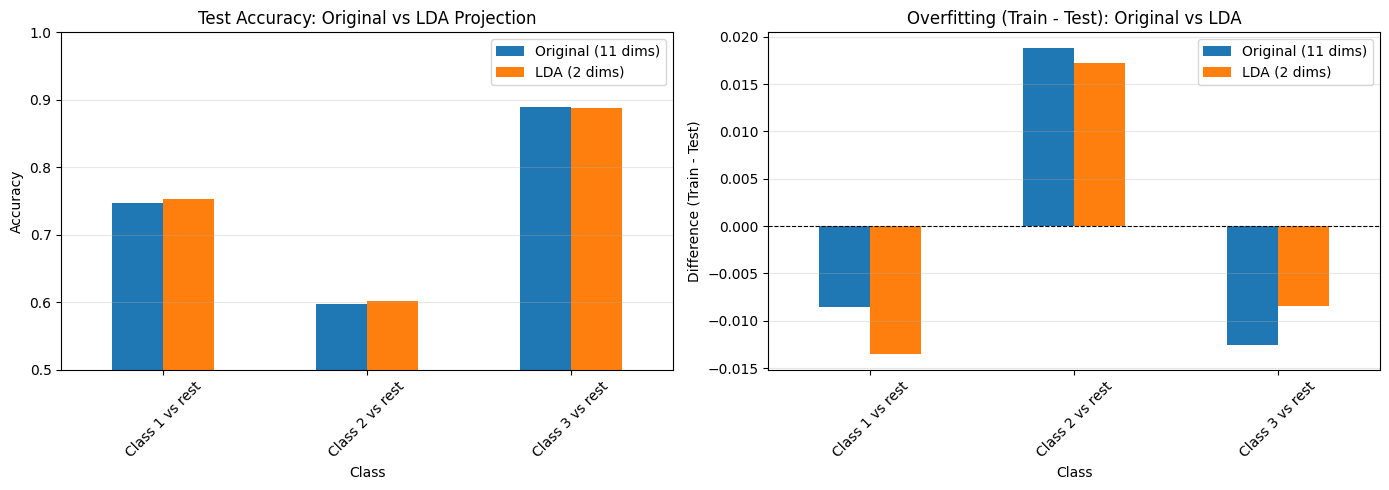

In [46]:
# Visualización de la comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Test Accuracy comparison
comparison_df.plot(x='Class', y=['Test_Original', 'Test_LDA'], 
                   kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Test Accuracy: Original vs LDA Projection')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.5, 1.0])
axes[0].legend(['Original (11 dims)', 'LDA (2 dims)'])
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Overfitting comparison (Train - Test)
comparison_df.plot(x='Class', y=['Diff_Original', 'Diff_LDA'], 
                   kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Overfitting (Train - Test): Original vs LDA')
axes[1].set_ylabel('Difference (Train - Test)')
axes[1].legend(['Original (11 dims)', 'LDA (2 dims)'])
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación de los resultados:**

En este caso podemos ver que apenas hay diferencia entre usar el LDA y los datos originales. 

Però en otras condiciones, por ejemplo con mas variables o más muestras, los datos originales probablemente tendrán mejor accuracy en test, ya que contienen toda la información discriminante de las variables fisicoquímicas. En cambio LDA reduce el espacio a solo 2 dimensiones, lo que puede causar pérdida de información, especialmente para separar clases que ya están solapadas.

En relación al overfitting, los datos originales, al tener más dimensiones (11), hay más riesgo de overfitting si no hay suficientes datos. Sin embargo, la regularización L2 controla esto. Y en la proyección LDA, al tener solo 2 dimensiones, el modelo es más simple y debería generalizar mejor (menor diferencia entre train y test), aunque debería tener menor accuracy absoluta (en este caso no sucede).

Normalmente es más dificil trabajar con los datos originales, debido a que suele haber mayor varianza, en cambio en LDA tenemos menos varianza pero más sesgo.

El LDA es útil cuando queremos visualización o cuando tenemos poco datos (reducir dimensiones ayuda), pero si tenemos suficientes datos, usar las características originales suele dar mejor resultado.

---
<font color='green'>   From the coefficients of the lda and  logistic linear classifiers, and the understanding of the problem, can you think of a feature engineering that might improve the problem</font>

Para proponer feature engineering útil, primero analicemos los coeficientes de los clasificadores logísticos y del LDA para entender qué relaciones son importantes para discriminar entre clases.

c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marcel\Uni\Master\MLEARN\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

LOGISTIC REGRESSION COEFFICIENTS (One-vs-Rest)
                      Class_1_vs_rest  Class_2_vs_rest  Class_3_vs_rest
fixed acidity                 -0.0593          -0.2339           0.5011
volatile acidity               0.4849          -0.2775          -0.3955
citric acid                    0.1321          -0.1908           0.1854
residual sugar                -0.0937          -0.0941           0.3382
chlorides                      0.2003          -0.0294          -0.3463
free sulfur dioxide           -0.3127           0.3475          -0.0486
total sulfur dioxide           0.6140          -0.4958          -0.4194
density                        0.1606           0.2563          -0.6357
pH                             0.1249          -0.1017           0.0407
sulphates                     -0.5455           0.1782           0.5968
alcohol                       -0.8305           0.3549           0.6889


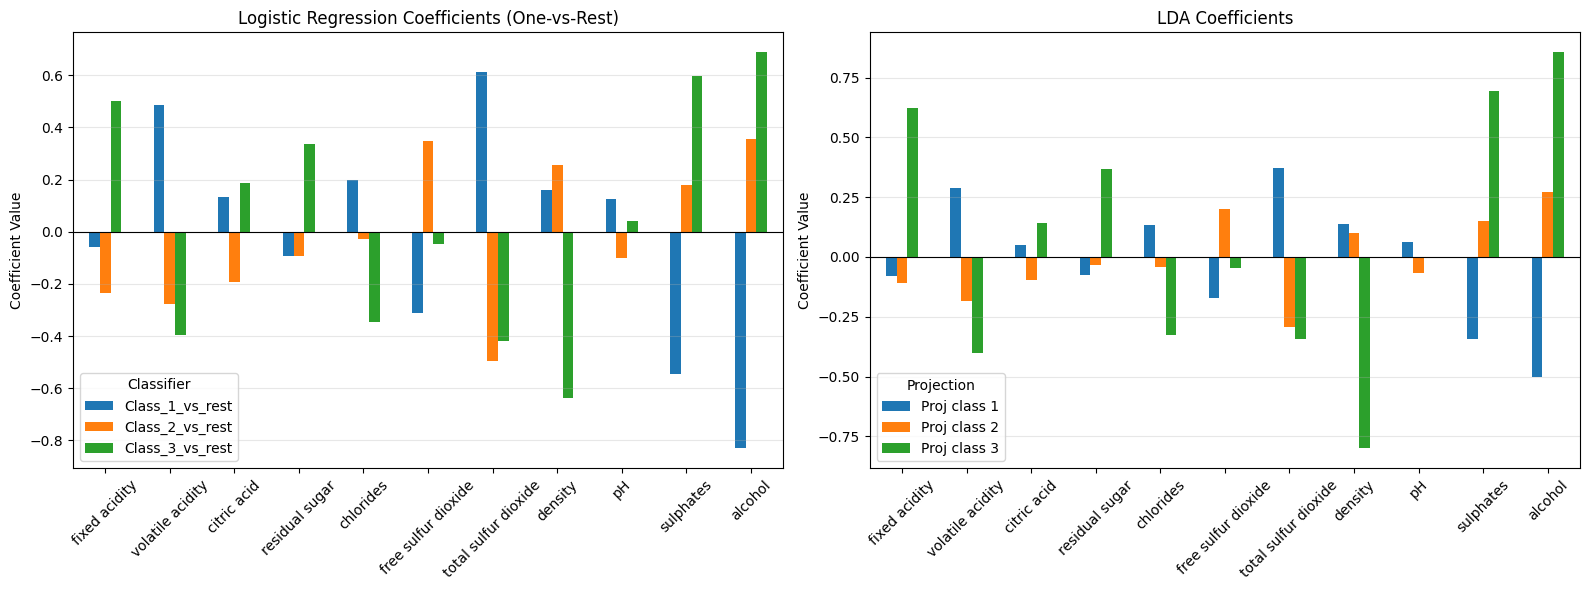

In [47]:
# Analizar coeficientes de los clasificadores logísticos
coef_dict = {}

for target_class in [1, 2, 3]:
    y_binary_train = (y == target_class).astype(int)
    clf = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    clf.fit(X, y_binary_train)
    coef_dict[f'Class_{target_class}_vs_rest'] = clf.coef_[0]

# Crear DataFrame con los coeficientes
coef_logistic = pd.DataFrame(coef_dict, index=InputFeatures)

print('='*70)
print('LOGISTIC REGRESSION COEFFICIENTS (One-vs-Rest)')
print('='*70)
print(coef_logistic.round(4))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Coeficientes Logistic Regression
coef_logistic.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Logistic Regression Coefficients (One-vs-Rest)')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend(title='Classifier')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Gráfico 2: Coeficientes LDA (ya calculados antes)
Coef_Lda.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('LDA Coefficients')
axes[1].set_ylabel('Coefficient Value')
axes[1].legend(title='Projection')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

**Propuestas de Feature Engineering:**

Basándonos en los coeficientes de LDA y los clasificadores logísticos, junto con el conocimiento del dominio del vino, podemos crear nuevas características que capturen relaciones no lineales o interacciones entre variables:

**1. Ratios de Acidez:**
- `total_acidity = fixed_acidity + volatile_acidity + citric_acid`: Acidez total
- `acidity_ratio = volatile_acidity / fixed_acidity`: La acidez volátil alta (acético) es mala, ratio importante

**3. Balance Alcohol-Acidez:**
- `alcohol_acidity_balance = alcohol / pH`: Vinos con más alcohol y baja acidez (pH alto) pueden ser mejores
- `alcohol_density_ratio = alcohol / density`: Relacionado con cuerpo del vino

**4. Características polinómicas:**
- `alcohol_squared = alcohol²`: Capturar efectos no lineales del alcohol (muy importante para calidad)
- `volatile_acidity_squared = volatile_acidity²`: Penalizar doblemente valores muy altos

Estas características capturan el balance entre acidez y alcohol y la importancia de controlar la acidez volátil.

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
